# Phase 10 — Deeper Analysis

Three classic SSL-paper plots that fall out almost for free given the
backbones we've already trained:

1. **Label efficiency** — train a linear probe on 1% / 10% / 50% / 100%
   of CIFAR-10 labels for each frozen backbone. SSL is supposed to
   dominate when labels are scarce.
2. **Embedding visualization** — t-SNE of the 512-d test features for
   the SimCLR / supervised / random backbones, colored by class.
3. **Per-class accuracy** — break the CIFAR-10 probe accuracy down by
   class and compare SimCLR vs. supervised. Includes confusion matrices.

Plus the same label-efficiency sweep on CIFAR-100 transfer features
(cached from Phase 8, so basically free).

No SSL training in this notebook — everything reuses checkpoints from
Phases 1–3 and the feature cache from Phase 8.


In [1]:
# --- Cell 1: Imports & Config ---
import json, os, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    CIFAR10_MEAN, CIFAR10_STD,
    get_device, get_cifar_resnet18, get_eval_transform,
)

cfg = dict(
    batch_size    = 256,
    probe_epochs  = 50,             # short — fits the small subsets too
    probe_lr      = 1e-3,
    weight_decay  = 1e-6,
    seed          = 42,
    num_workers   = 0,
    data_root     = './data',
    feat_dir      = 'results/features',
    results_path  = 'results/deeper_analysis.json',
    label_fracs   = [0.01, 0.1, 0.5, 1.0],   # 1% / 10% / 50% / 100%
)
torch.manual_seed(cfg['seed']); np.random.seed(cfg['seed'])
os.makedirs('figures', exist_ok=True)
os.makedirs(cfg['feat_dir'], exist_ok=True)
device = get_device()
print('Device:', device)
print('Config:', cfg)

BACKBONES = {
    'simclr':     'models/simclr_baseline.pth',
    'supervised': 'models/supervised_baseline.pth',
    'random':     'models/random_baseline_backbone.pth',
}


Device: privateuseone:0
Config: {'batch_size': 256, 'probe_epochs': 50, 'probe_lr': 0.001, 'weight_decay': 1e-06, 'seed': 42, 'num_workers': 0, 'data_root': './data', 'feat_dir': 'results/features', 'results_path': 'results/deeper_analysis.json', 'label_fracs': [0.01, 0.1, 0.5, 1.0]}


In [2]:
# --- Cell 2: Backbones + CIFAR-10 ---
def load_backbone(name: str, path: str) -> nn.Module:
    ck = torch.load(path, map_location='cpu', weights_only=False)
    bb = get_cifar_resnet18()
    if name == 'random':
        bb.load_state_dict(ck['state_dict'])
    else:
        state = ck['model_state']
        bb_state = {k[len('backbone.'):]: v for k, v in state.items()
                    if k.startswith('backbone.')}
        bb.load_state_dict(bb_state, strict=False)
    for p in bb.parameters(): p.requires_grad = False
    bb.eval()
    return bb.to(device)

eval_transform = get_eval_transform(32)
train_ds = CIFAR10(cfg['data_root'], train=True,  download=True, transform=eval_transform)
test_ds  = CIFAR10(cfg['data_root'], train=False, download=True, transform=eval_transform)
print(f'CIFAR-10: train={len(train_ds)} test={len(test_ds)}')


Files already downloaded and verified


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
CIFAR-10: train=50000 test=10000


In [3]:
# --- Cell 3: Extract & cache CIFAR-10 features per backbone ---
@torch.no_grad()
def extract_features(bb: nn.Module, ds) -> tuple[torch.Tensor, torch.Tensor]:
    loader = DataLoader(ds, batch_size=512, shuffle=False,
                        num_workers=cfg['num_workers'], pin_memory=False)
    feats, labels = [], []
    for x, y in loader:
        x = x.to(device)
        h = bb(x).cpu()
        feats.append(h); labels.append(y)
    return torch.cat(feats), torch.cat(labels)

def cached_features(name: str, split: str):
    fpath = os.path.join(cfg['feat_dir'], f'cifar10_{name}_{split}.pt')
    lpath = os.path.join(cfg['feat_dir'], f'cifar10_{name}_{split}_labels.pt')
    if os.path.exists(fpath) and os.path.exists(lpath):
        return torch.load(fpath), torch.load(lpath)
    return None

def ensure_features(name: str, path: str):
    cached_tr = cached_features(name, 'train')
    cached_te = cached_features(name, 'test')
    if cached_tr is not None and cached_te is not None:
        print(f'  [{name}] cached')
        return cached_tr + cached_te          # (Xtr, ytr, Xte, yte)
    print(f'  [{name}] extracting...')
    bb = load_backbone(name, path)
    Xtr, ytr = extract_features(bb, train_ds)
    Xte, yte = extract_features(bb, test_ds)
    torch.save(Xtr, os.path.join(cfg['feat_dir'], f'cifar10_{name}_train.pt'))
    torch.save(ytr, os.path.join(cfg['feat_dir'], f'cifar10_{name}_train_labels.pt'))
    torch.save(Xte, os.path.join(cfg['feat_dir'], f'cifar10_{name}_test.pt'))
    torch.save(yte, os.path.join(cfg['feat_dir'], f'cifar10_{name}_test_labels.pt'))
    del bb
    return Xtr, ytr, Xte, yte

feats = {}                                    # name -> (Xtr, ytr, Xte, yte)
for name, path in BACKBONES.items():
    feats[name] = ensure_features(name, path)
print('feature shapes:',
      {k: tuple(v[0].shape) for k, v in feats.items()})


  [simclr] extracting...
  [supervised] extracting...
  [random] extracting...
feature shapes: {'simclr': (50000, 512), 'supervised': (50000, 512), 'random': (50000, 512)}


In [4]:
# --- Cell 4: Train a linear probe on a feature subset ---
def label_subset_indices(labels: torch.Tensor, frac: float, seed: int = 42) -> np.ndarray:
    """Stratified per-class subset so 1% still has every class."""
    if frac >= 1.0:
        return np.arange(len(labels))
    rng = np.random.default_rng(seed)
    out = []
    y = labels.numpy()
    for c in np.unique(y):
        idx = np.where(y == c)[0]
        k = max(1, int(round(len(idx) * frac)))
        out.append(rng.choice(idx, size=k, replace=False))
    return np.concatenate(out)

def probe_on_features(Xtr, ytr, Xte, yte, n_classes: int, epochs: int = None) -> dict:
    epochs = epochs or cfg['probe_epochs']
    Xtr = Xtr.to(device); ytr = ytr.to(device)
    Xte = Xte.to(device); yte = yte.to(device)

    head = nn.Linear(Xtr.shape[1], n_classes).to(device)
    opt  = torch.optim.Adam(head.parameters(), lr=cfg['probe_lr'],
                            weight_decay=cfg['weight_decay'])
    bs = cfg['batch_size']
    n  = Xtr.shape[0]
    best, hist = 0.0, []
    for ep in range(1, epochs+1):
        head.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            logits = head(Xtr[idx])
            loss = F.cross_entropy(logits, ytr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        head.eval()
        with torch.no_grad():
            pred = head(Xte).argmax(1)
            acc  = (pred == yte).float().mean().item()
        hist.append(acc); best = max(best, acc)
    return dict(final=hist[-1], best=best, curve=hist)


In [5]:
# --- Cell 5: Label efficiency on CIFAR-10 ---
results = {'cifar10_label_efficiency': {}}
for name in BACKBONES:
    Xtr, ytr, Xte, yte = feats[name]
    per_frac = {}
    for frac in cfg['label_fracs']:
        idx = label_subset_indices(ytr, frac, seed=cfg['seed'])
        sub_X, sub_y = Xtr[idx], ytr[idx]
        # tiny subsets need more epochs to converge, big ones don't gain
        ep = 100 if frac <= 0.1 else cfg['probe_epochs']
        out = probe_on_features(sub_X, sub_y, Xte, yte, n_classes=10, epochs=ep)
        print(f'  {name:10s} frac={frac:>5.2f}  n={len(idx):>5d}  '
              f'final={out["final"]*100:5.2f}%  best={out["best"]*100:5.2f}%')
        per_frac[str(frac)] = out
    results['cifar10_label_efficiency'][name] = per_frac


c:\Users\Michael\Documents\Graduate\2026\535505人工智慧 Artificial Intelligence\HW\SelfSupervisedAIHW2\hw2_env\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


  simclr     frac= 0.01  n=  500  final=80.76%  best=80.88%
  simclr     frac= 0.10  n= 5000  final=84.05%  best=84.25%
  simclr     frac= 0.50  n=25000  final=85.98%  best=86.31%
  simclr     frac= 1.00  n=50000  final=86.41%  best=86.66%
  supervised frac= 0.01  n=  500  final=91.39%  best=91.45%
  supervised frac= 0.10  n= 5000  final=91.71%  best=91.74%
  supervised frac= 0.50  n=25000  final=91.83%  best=91.92%
  supervised frac= 1.00  n=50000  final=92.05%  best=92.10%
  random     frac= 0.01  n=  500  final=26.48%  best=26.73%
  random     frac= 0.10  n= 5000  final=34.43%  best=34.59%
  random     frac= 0.50  n=25000  final=37.61%  best=38.51%
  random     frac= 1.00  n=50000  final=40.33%  best=40.41%


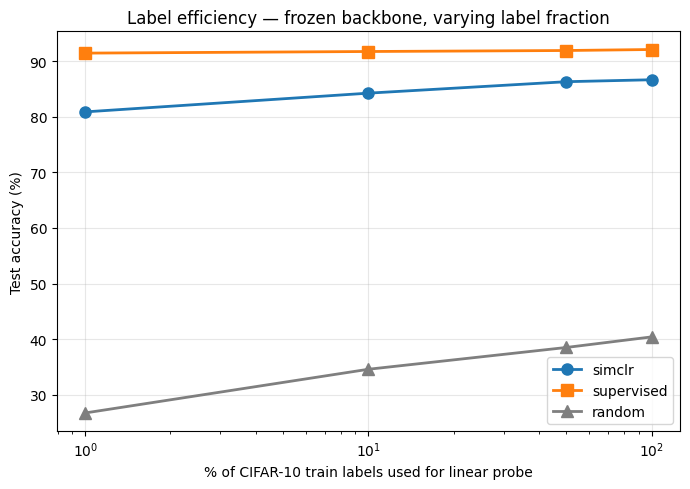

Saved figures/fig8_label_efficiency_cifar10.png


In [6]:
# --- Cell 6: Plot CIFAR-10 label-efficiency curves ---
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'simclr': 'tab:blue', 'supervised': 'tab:orange', 'random': 'tab:gray'}
markers = {'simclr': 'o', 'supervised': 's', 'random': '^'}
for name, per_frac in results['cifar10_label_efficiency'].items():
    xs = sorted(float(f) for f in per_frac.keys())
    ys = [per_frac[str(f)]['best'] * 100 for f in xs]
    ax.plot([f*100 for f in xs], ys, marker=markers[name], color=colors[name],
            label=name, linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xlabel('% of CIFAR-10 train labels used for linear probe')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Label efficiency — frozen backbone, varying label fraction')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('figures/fig8_label_efficiency_cifar10.png', dpi=150)
plt.show()
print('Saved figures/fig8_label_efficiency_cifar10.png')


  t-SNE [random]...
    done in 5.0s
  t-SNE [simclr]...
    done in 2.6s
  t-SNE [supervised]...
    done in 2.3s


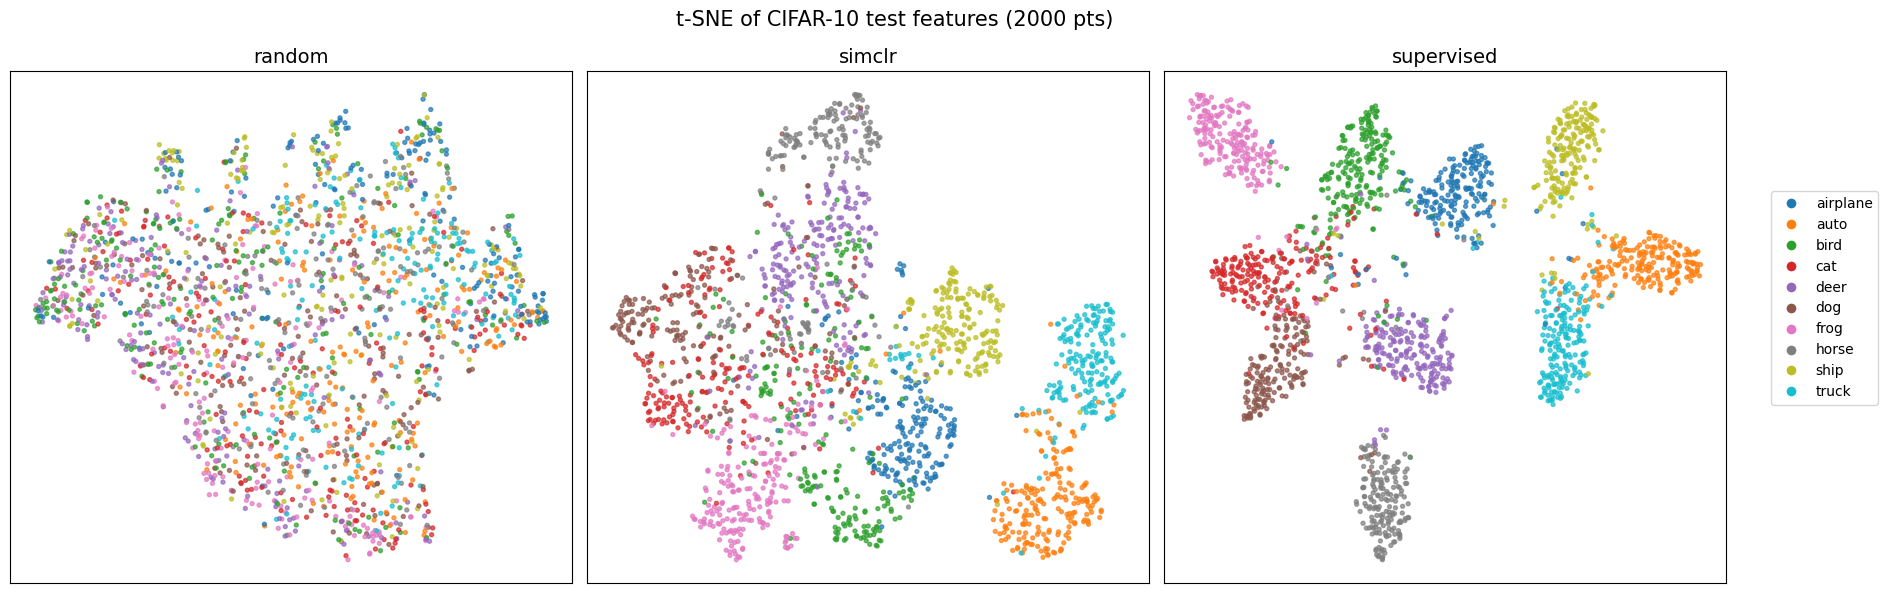

Saved figures/fig9_tsne_features.png


In [7]:
# --- Cell 7: t-SNE of test features ---
from sklearn.manifold import TSNE

# 2000 random test points keeps t-SNE under a minute and the plot readable
N_TSNE = 2000
rng = np.random.default_rng(cfg['seed'])
sub_idx = rng.choice(10000, size=N_TSNE, replace=False)

CIFAR10_CLASSES = ['airplane','auto','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
embeds = {}
for ax, name in zip(axes, ['random', 'simclr', 'supervised']):
    Xte, yte = feats[name][2], feats[name][3]
    X = Xte[sub_idx].numpy()
    y = yte[sub_idx].numpy()
    print(f'  t-SNE [{name}]...', flush=True)
    t0 = time.time()
    Z = TSNE(n_components=2, perplexity=30, init='pca',
             random_state=cfg['seed']).fit_transform(X)
    print(f'    done in {time.time()-t0:.1f}s')
    embeds[name] = (Z, y)
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap='tab10', s=8, alpha=0.7)
    ax.set_title(f'{name}', fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])
# one legend for all three panels
handles = [plt.Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=plt.cm.tab10(i/10), markersize=8,
                      label=CIFAR10_CLASSES[i]) for i in range(10)]
fig.legend(handles=handles, loc='center right', ncol=1, frameon=True,
           bbox_to_anchor=(1.05, 0.5))
plt.suptitle('t-SNE of CIFAR-10 test features (2000 pts)', fontsize=15)
plt.tight_layout(rect=(0, 0, 0.97, 1.0))
plt.savefig('figures/fig9_tsne_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/fig9_tsne_features.png')


  full probe [simclr]...
  full probe [supervised]...


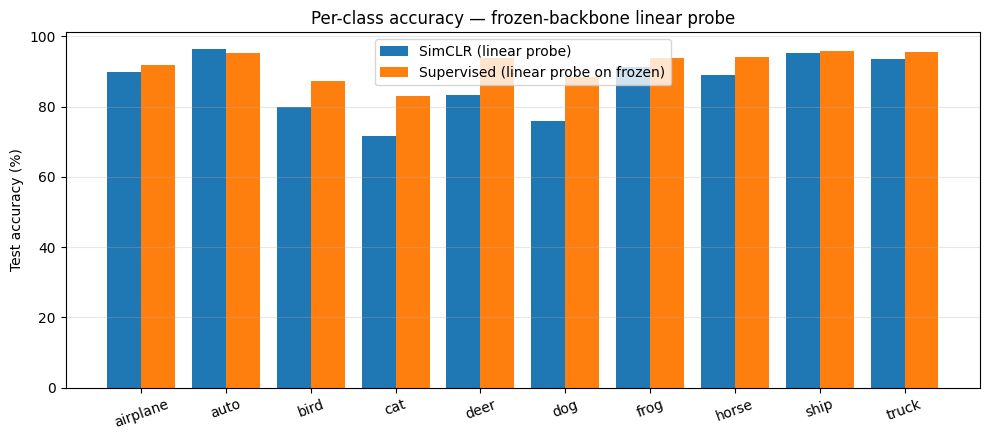

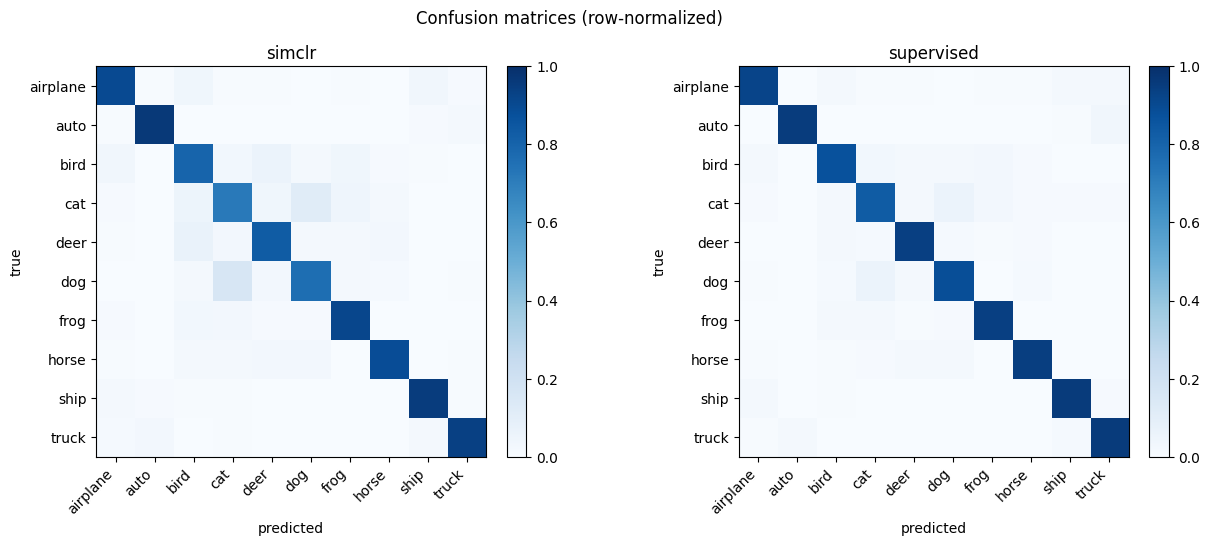

Saved fig10_per_class_accuracy.png + fig10b_confusion_matrices.png


In [8]:
# --- Cell 8: Per-class accuracy + confusion matrices ---
# Train a fresh linear probe on full data for simclr & supervised, then
# break the test predictions out by class.
from sklearn.metrics import confusion_matrix

def train_full_probe(name: str):
    Xtr, ytr, Xte, yte = feats[name]
    Xtr_d, ytr_d = Xtr.to(device), ytr.to(device)
    Xte_d, yte_d = Xte.to(device), yte.to(device)
    head = nn.Linear(512, 10).to(device)
    opt  = torch.optim.Adam(head.parameters(), lr=cfg['probe_lr'],
                            weight_decay=cfg['weight_decay'])
    bs, n = cfg['batch_size'], Xtr_d.shape[0]
    for ep in range(cfg['probe_epochs']):
        head.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, bs):
            idx = perm[i:i+bs]
            loss = F.cross_entropy(head(Xtr_d[idx]), ytr_d[idx])
            opt.zero_grad(); loss.backward(); opt.step()
    head.eval()
    with torch.no_grad():
        pred = head(Xte_d).argmax(1).cpu().numpy()
    return pred, yte.numpy()

probes = {}
for name in ['simclr', 'supervised']:
    print(f'  full probe [{name}]...', flush=True)
    pred, true = train_full_probe(name)
    probes[name] = (pred, true)

# per-class accuracy
per_class = {}
for name, (pred, true) in probes.items():
    accs = []
    for c in range(10):
        mask = true == c
        accs.append(float((pred[mask] == c).mean()))
    per_class[name] = accs
results['cifar10_per_class_accuracy'] = per_class

# bar chart
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(10); w = 0.4
ax.bar(x - w/2, [a*100 for a in per_class['simclr']],     width=w,
       color='tab:blue',   label='SimCLR (linear probe)')
ax.bar(x + w/2, [a*100 for a in per_class['supervised']], width=w,
       color='tab:orange', label='Supervised (linear probe on frozen)')
ax.set_xticks(x); ax.set_xticklabels(CIFAR10_CLASSES, rotation=20)
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Per-class accuracy — frozen-backbone linear probe')
ax.grid(True, axis='y', alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('figures/fig10_per_class_accuracy.png', dpi=150)
plt.show()

# confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, name in zip(axes, ['simclr', 'supervised']):
    pred, true = probes[name]
    cm = confusion_matrix(true, pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')
    ax.set_yticklabels(CIFAR10_CLASSES)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(f'{name}')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle('Confusion matrices (row-normalized)')
plt.tight_layout()
plt.savefig('figures/fig10b_confusion_matrices.png', dpi=150)
plt.show()
print('Saved fig10_per_class_accuracy.png + fig10b_confusion_matrices.png')


  cifar100 simclr     frac= 0.01  final=19.97%  best=20.13%
  cifar100 simclr     frac= 0.10  final=36.50%  best=36.55%
  cifar100 simclr     frac= 0.50  final=45.66%  best=45.68%
  cifar100 simclr     frac= 1.00  final=49.43%  best=49.43%
  cifar100 supervised frac= 0.01  final=15.47%  best=15.50%
  cifar100 supervised frac= 0.10  final=35.51%  best=35.56%
  cifar100 supervised frac= 0.50  final=43.27%  best=43.63%
  cifar100 supervised frac= 1.00  final=47.07%  best=47.14%
  cifar100 random     frac= 0.01  final= 6.60%  best= 6.72%
  cifar100 random     frac= 0.10  final=10.95%  best=11.45%
  cifar100 random     frac= 0.50  final=15.26%  best=15.26%
  cifar100 random     frac= 1.00  final=17.70%  best=17.93%


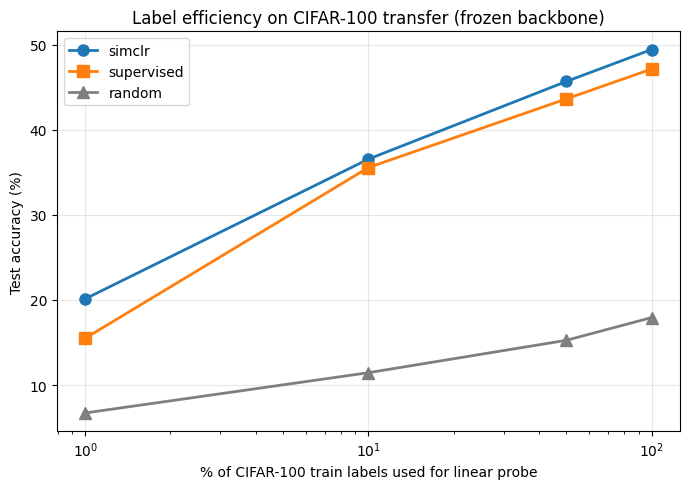

Saved figures/fig11_label_efficiency_cifar100.png


In [9]:
# --- Cell 9: Label efficiency on CIFAR-100 transfer (cached features) ---
# Phase 8 already cached cifar100_<bb>_{train,test}.pt — reuse them.

CFAR100_CACHE_OK = all(
    os.path.exists(os.path.join(cfg['feat_dir'], f'cifar100_{n}_{s}.pt'))
    for n in BACKBONES for s in ('train', 'test')
)
if not CFAR100_CACHE_OK:
    print('CIFAR-100 transfer cache missing — run Phase 8 first.')
else:
    cifar100_results = {}
    for name in BACKBONES:
        d = torch.load(os.path.join(cfg['feat_dir'], f'cifar100_{name}_train.pt'),
                       weights_only=False)
        # Phase 8's cache stores {'features': ..., 'labels': ...} dicts
        Xtr = d['features'] if isinstance(d, dict) else d[0]
        ytr = d['labels']   if isinstance(d, dict) else d[1]
        d2 = torch.load(os.path.join(cfg['feat_dir'], f'cifar100_{name}_test.pt'),
                        weights_only=False)
        Xte = d2['features'] if isinstance(d2, dict) else d2[0]
        yte = d2['labels']   if isinstance(d2, dict) else d2[1]
        per_frac = {}
        for frac in cfg['label_fracs']:
            idx = label_subset_indices(ytr, frac, seed=cfg['seed'])
            ep = 100 if frac <= 0.1 else cfg['probe_epochs']
            out = probe_on_features(Xtr[idx], ytr[idx], Xte, yte,
                                    n_classes=100, epochs=ep)
            print(f'  cifar100 {name:10s} frac={frac:>5.2f}  '
                  f'final={out["final"]*100:5.2f}%  best={out["best"]*100:5.2f}%')
            per_frac[str(frac)] = out
        cifar100_results[name] = per_frac
    results['cifar100_label_efficiency'] = cifar100_results

    # plot
    fig, ax = plt.subplots(figsize=(7, 5))
    for name, per_frac in cifar100_results.items():
        xs = sorted(float(f) for f in per_frac.keys())
        ys = [per_frac[str(f)]['best']*100 for f in xs]
        ax.plot([f*100 for f in xs], ys, marker=markers[name], color=colors[name],
                label=name, linewidth=2, markersize=8)
    ax.set_xscale('log')
    ax.set_xlabel('% of CIFAR-100 train labels used for linear probe')
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title('Label efficiency on CIFAR-100 transfer (frozen backbone)')
    ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout()
    plt.savefig('figures/fig11_label_efficiency_cifar100.png', dpi=150)
    plt.show()
    print('Saved figures/fig11_label_efficiency_cifar100.png')


In [10]:
# --- Cell 10: Save results + summary table ---
with open(cfg['results_path'], 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved {cfg["results_path"]}')

# CIFAR-10 label efficiency table
print()
print('CIFAR-10 label efficiency (best test acc):')
print('=' * 60)
print(f'{"backbone":<12s}' + ''.join(f'{int(f*100):>10d}%' for f in cfg['label_fracs']))
print('-' * 60)
for name, per_frac in results['cifar10_label_efficiency'].items():
    row = f'{name:<12s}'
    for f in cfg['label_fracs']:
        row += f'  {per_frac[str(f)]["best"]*100:6.2f}%  '
    print(row)

if 'cifar100_label_efficiency' in results:
    print()
    print('CIFAR-100 transfer label efficiency (best test acc):')
    print('=' * 60)
    print(f'{"backbone":<12s}' + ''.join(f'{int(f*100):>10d}%' for f in cfg['label_fracs']))
    print('-' * 60)
    for name, per_frac in results['cifar100_label_efficiency'].items():
        row = f'{name:<12s}'
        for f in cfg['label_fracs']:
            row += f'  {per_frac[str(f)]["best"]*100:6.2f}%  '
        print(row)


Saved results/deeper_analysis.json

CIFAR-10 label efficiency (best test acc):
backbone             1%        10%        50%       100%
------------------------------------------------------------
simclr         80.88%     84.25%     86.31%     86.66%  
supervised     91.45%     91.74%     91.92%     92.10%  
random         26.73%     34.59%     38.51%     40.41%  

CIFAR-100 transfer label efficiency (best test acc):
backbone             1%        10%        50%       100%
------------------------------------------------------------
simclr         20.13%     36.55%     45.68%     49.43%  
supervised     15.50%     35.56%     43.63%     47.14%  
random          6.72%     11.45%     15.26%     17.93%  
